In [21]:
from data_augmentation.generator.noisy_matrices_generator import NoisyMatricesGenerator
from data_augmentation.generator.coherent_matrices_generator import CoherentMatricesGenerator
from data_augmentation.data_loader import DataLoader
from visualization.data.matrices_visualizator import MatricesVisualizator
from analytic_methods.EVM_method import EVM
from metrics.evaluator import Evaluator
import numpy as np

In [22]:
coherent_generator = CoherentMatricesGenerator(10, 5)
coherence_rates = [i/100 for i in range(1, 10)]
noisy_rates = [0.01, 0.02, 0.03, 0.05, 0.07, 0.1, 0.15, 0.2, 0.3, 0.4]

matrix_coh, weights_coh = coherent_generator.generate()

for rate in noisy_rates:
    noisy_generator = NoisyMatricesGenerator(10, 5, rate)

    matrix_noisy, weigths_noisy = noisy_generator.generate()
    coherent_generator.save()
    noisy_generator.save()

Zapisano spójne macierze w: data/synthetic_data/coherent
Zapisano zaszumione macierze w: data/synthetic_data/noisy
Zapisano spójne macierze w: data/synthetic_data/coherent
Zapisano zaszumione macierze w: data/synthetic_data/noisy
Zapisano spójne macierze w: data/synthetic_data/coherent
Zapisano zaszumione macierze w: data/synthetic_data/noisy
Zapisano spójne macierze w: data/synthetic_data/coherent
Zapisano zaszumione macierze w: data/synthetic_data/noisy
Zapisano spójne macierze w: data/synthetic_data/coherent
Zapisano zaszumione macierze w: data/synthetic_data/noisy
Zapisano spójne macierze w: data/synthetic_data/coherent
Zapisano zaszumione macierze w: data/synthetic_data/noisy
Zapisano spójne macierze w: data/synthetic_data/coherent
Zapisano zaszumione macierze w: data/synthetic_data/noisy
Zapisano spójne macierze w: data/synthetic_data/coherent
Zapisano zaszumione macierze w: data/synthetic_data/noisy
Zapisano spójne macierze w: data/synthetic_data/coherent
Zapisano zaszumione mac

In [23]:

loader = DataLoader()

matrix_coh, weights_coh = loader.load_coherent_matrices()
matrix_noisy, weigths_noisy = loader.load_noisy_matrices(0.01)

noisy_matrixes_list = []
noisy_weights_list = []
for level in noisy_rates:
    matrix_noisy, weigths_noisy = loader.load_noisy_matrices(level)
    noisy_matrixes_list.append(matrix_noisy[0])
    noisy_weights_list.append(weigths_noisy[0])
matrix_coh, weights_coh

Pomyślnie wczytano 10 spójnych macierzy.
Pomyślnie wczytano 10 zaszumionych macierzy (poziom: c001).
Pomyślnie wczytano 10 zaszumionych macierzy (poziom: c001).
Pomyślnie wczytano 10 zaszumionych macierzy (poziom: c002).
Pomyślnie wczytano 10 zaszumionych macierzy (poziom: c003).
Pomyślnie wczytano 10 zaszumionych macierzy (poziom: c005).
Pomyślnie wczytano 10 zaszumionych macierzy (poziom: c007).
Pomyślnie wczytano 10 zaszumionych macierzy (poziom: c010).
Pomyślnie wczytano 10 zaszumionych macierzy (poziom: c015).
Pomyślnie wczytano 10 zaszumionych macierzy (poziom: c020).
Pomyślnie wczytano 10 zaszumionych macierzy (poziom: c030).
Pomyślnie wczytano 10 zaszumionych macierzy (poziom: c040).


(array([[[1.        , 0.12247529, 0.13538126, 0.2301647 , 0.90347968],
         [8.16491212, 1.        , 1.10537613, 1.87927455, 7.3768322 ],
         [7.38654645, 0.90466944, 1.        , 1.70012225, 6.67359463],
         [4.34471488, 0.53212023, 0.588193  , 1.        , 3.92536162],
         [1.10683175, 0.13555954, 0.14984428, 0.2547536 , 1.        ]],
 
        [[1.        , 0.74552011, 2.64714788, 0.84895862, 0.93997947],
         [1.34134543, 1.        , 3.55073972, 1.13874677, 1.26083717],
         [0.37776507, 0.28163146, 1.        , 0.32070691, 0.35509141],
         [1.17791371, 0.87815837, 3.11811179, 1.        , 1.10721471],
         [1.06385302, 0.79312383, 2.81617627, 0.90316719, 1.        ]],
 
        [[1.        , 0.74552402, 0.38974922, 0.54560089, 1.21191599],
         [1.3413384 , 1.        , 0.52278559, 0.73183542, 1.62558945],
         [2.56575242, 1.91283007, 1.        , 1.39987679, 3.10947639],
         [1.8328416 , 1.36642745, 0.71434858, 1.        , 2.22125005],


/home/konra/semestr6/sieci_neuronowe/NN-preference-modeling/visualization/data/matrices_visualizator.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=criteria_labels, y=weights, palette="viridis")


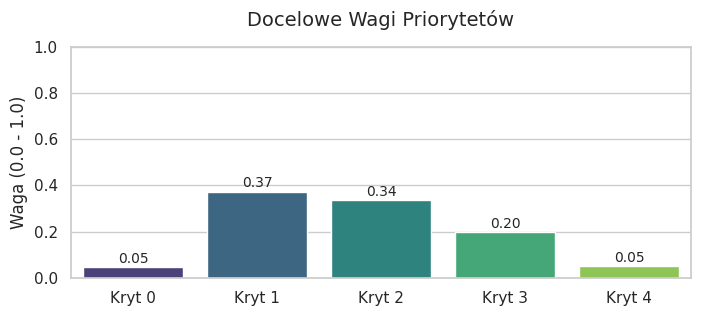

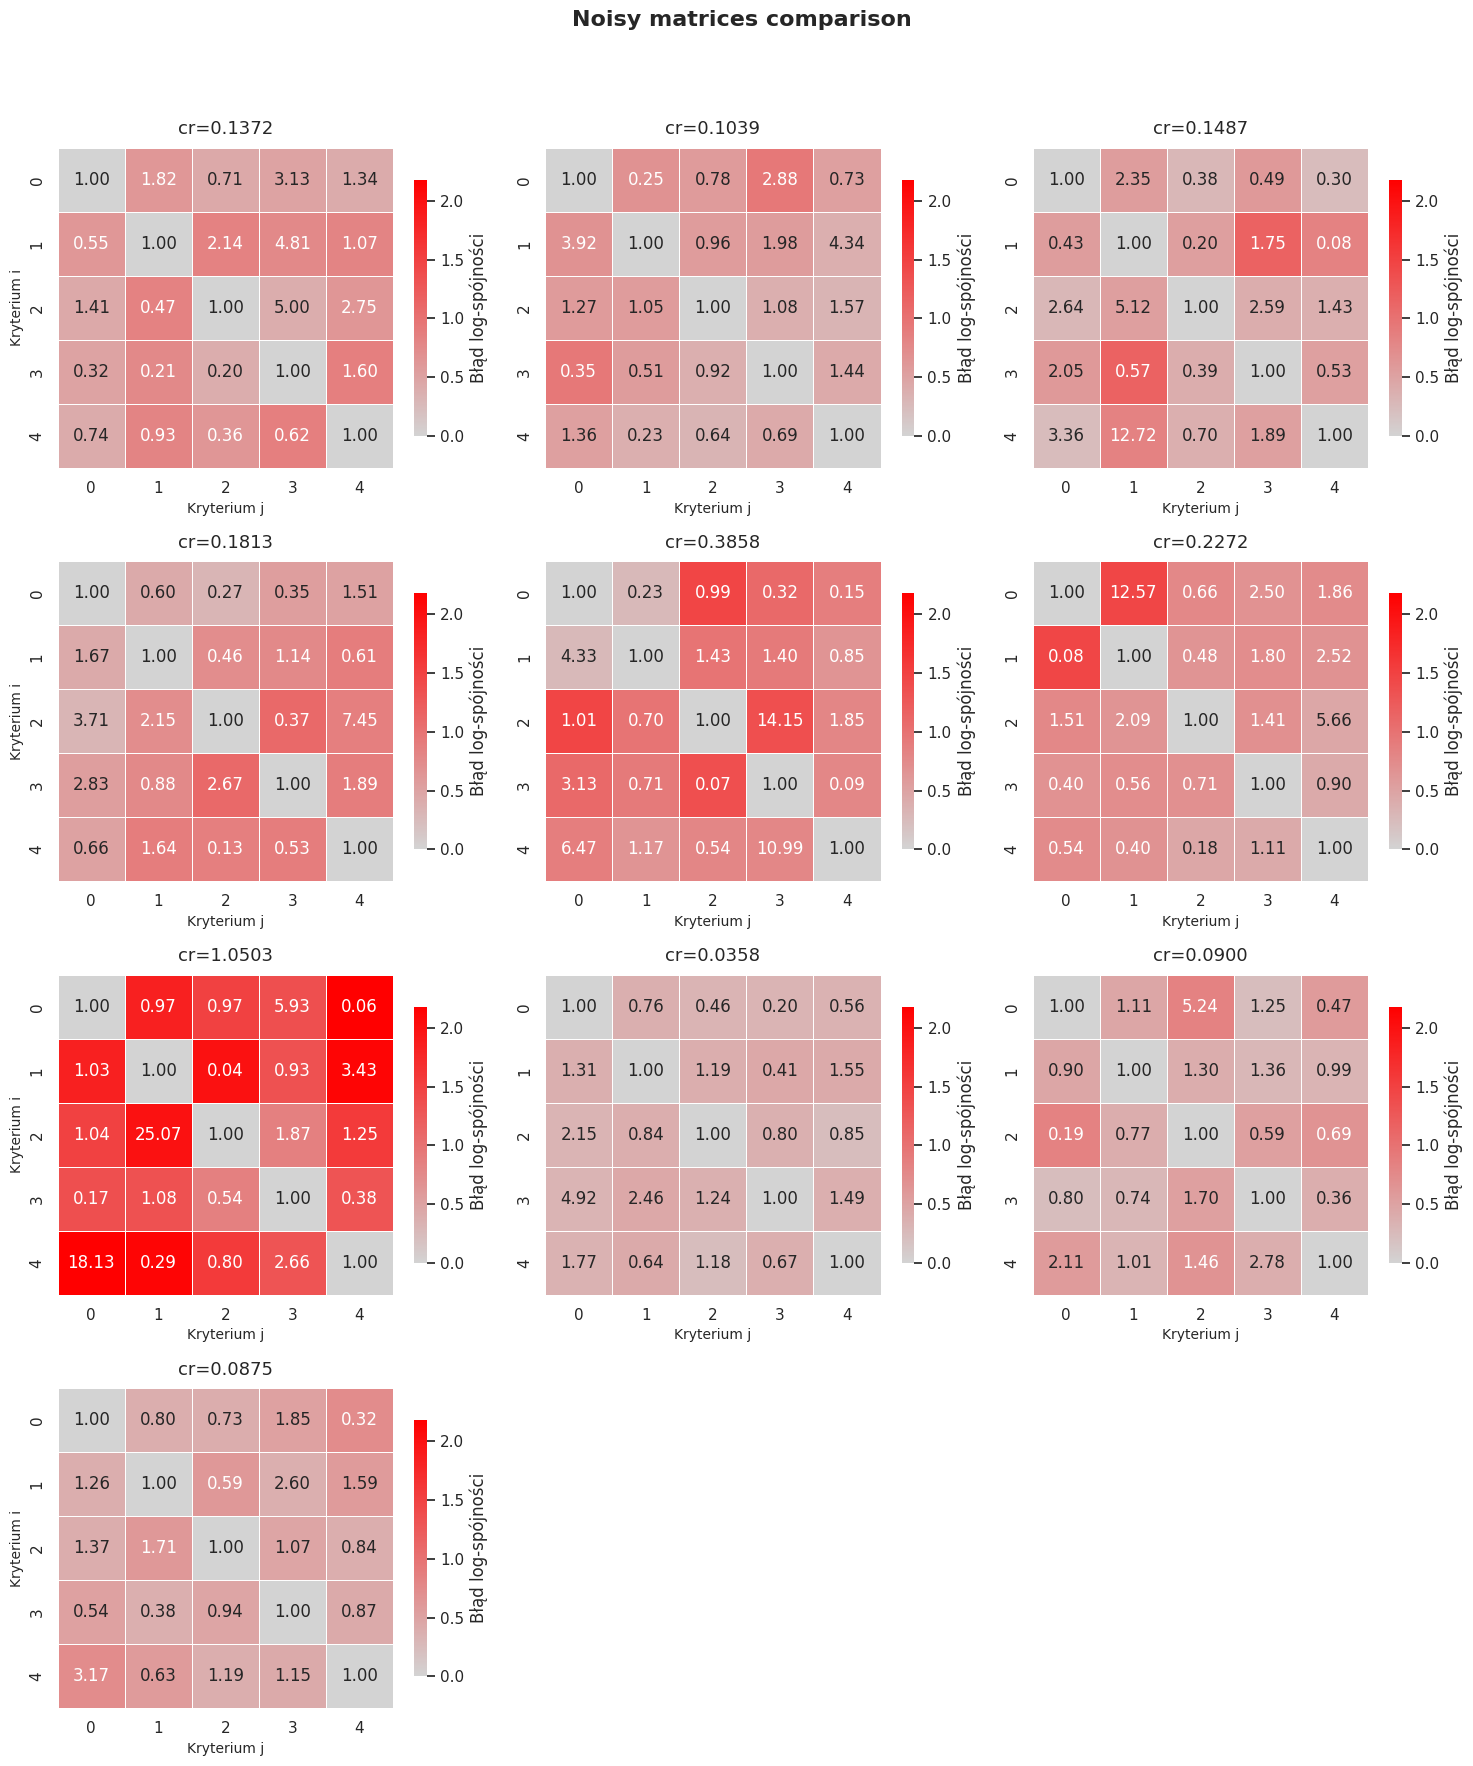

In [24]:
evm = EVM()

m_clean = matrix_coh[0]
m_noisy = matrix_noisy[0]
w_target = weights_coh[0]
consistency_ratios = []

for matrix in noisy_matrixes_list:
    w_noised_computed, consistency_ratio = evm.compute_single(matrix)
    consistency_ratios.append(consistency_ratio)

w_noised = weigths_noisy[0]

viz = MatricesVisualizator()

viz.plot_weights(w_target)
# viz.plot_weights_comparison(w_noised, w_noised_computed, consistency_ratio)
# viz.compare_matrices(m_clean, m_noisy, coherence_rate=consistency_ratio)
viz.noisy_matrices_comparison(noisy_matrixes_list, consistency_ratios)

Pomyślnie wczytano 10 zaszumionych macierzy (poziom: c001).
Pomyślnie wczytano 10 zaszumionych macierzy (poziom: c002).
Pomyślnie wczytano 10 zaszumionych macierzy (poziom: c003).
Pomyślnie wczytano 10 zaszumionych macierzy (poziom: c005).
Pomyślnie wczytano 10 zaszumionych macierzy (poziom: c007).
Pomyślnie wczytano 10 zaszumionych macierzy (poziom: c010).
Pomyślnie wczytano 10 zaszumionych macierzy (poziom: c015).
Pomyślnie wczytano 10 zaszumionych macierzy (poziom: c020).
Pomyślnie wczytano 10 zaszumionych macierzy (poziom: c030).
Pomyślnie wczytano 10 zaszumionych macierzy (poziom: c040).
Średni CR w zbiorze: 0.245
Średni błąd MAE: 0.0491
Średnia korelacja Kendalla: 0.5600


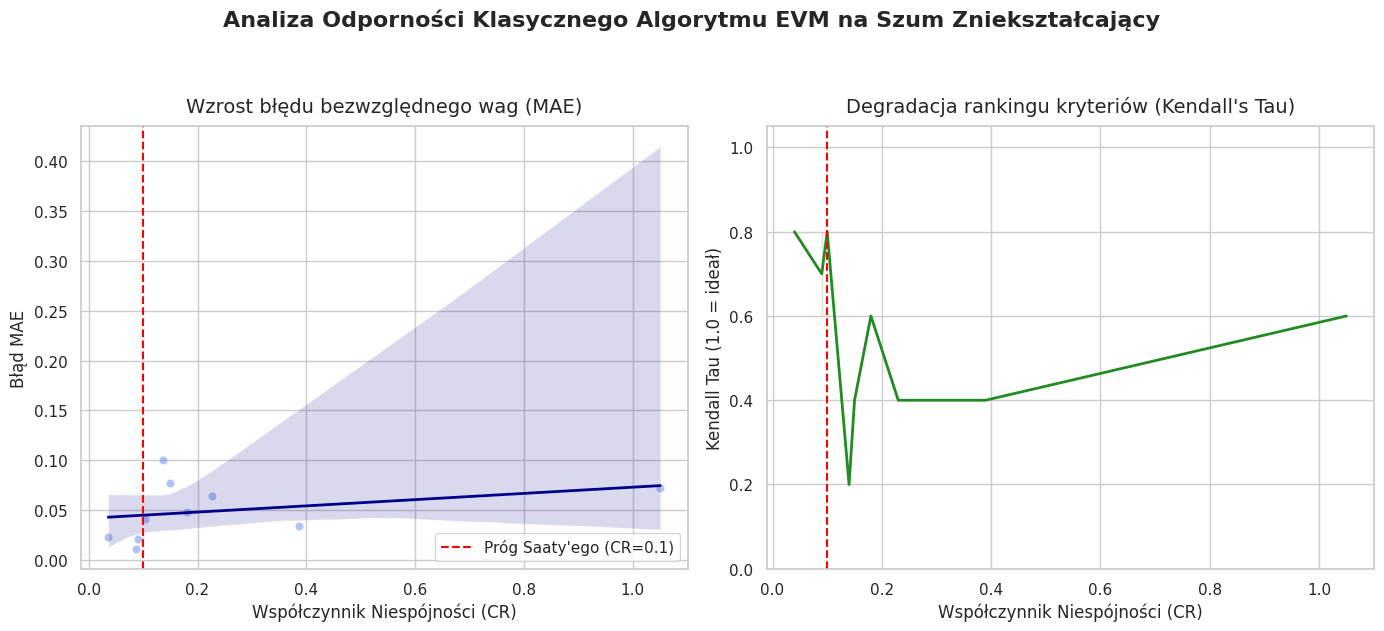

In [ ]:
loader = DataLoader()
noisy_matrixes_list = []
noisy_weights_list = []
noisy_rates = [0.01, 0.02, 0.03, 0.05, 0.07, 0.1, 0.15, 0.2, 0.3, 0.4]

for level in noisy_rates:
    matrix_noisy, weigths_noisy = loader.load_noisy_matrices(level)
    noisy_matrixes_list.append(matrix_noisy[0])
    noisy_weights_list.append(weigths_noisy[0])


evm_solver = EVM()
evm_weights, cr_values = evm_solver.compute_batch(np.array(noisy_matrixes_list))

evaluator = Evaluator()
mae_errors, kendall_taus = evaluator.evaluate_batch(np.array(noisy_weights_list), evm_weights)


print(f"Średni CR w zbiorze: {np.mean(cr_values):.3f}")
print(f"Średni błąd MAE: {np.mean(mae_errors):.4f}")
print(f"Średnia korelacja Kendalla: {np.mean(kendall_taus):.4f}")

viz = MatricesVisualizator()
viz.plot_evm_degradation(cr_values, mae_errors, kendall_taus)